# **TRAVELING SALESMAN PROBLEM SOLVED BY 4 LOCAL AND META ALG**
**BY: MAHA MOHAMMED ALOSAIMI 44780314**

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import pandas as pd
import numpy as np
import random
from sys import maxsize
import matplotlib.cm as cm
import itertools
from collections import defaultdict
import matplotlib.pyplot as plt
from itertools import permutations
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial import distance_matrix
import plotly.graph_objects as go

# **Load the dataset**

In [ ]:
!git clone https://github.com/Mahaalosaimi2000/TSP_KSA.git

fatal: destination path 'TSP_KSA' already exists and is not an empty directory.


In [ ]:
ksa_data_path = '/content/TSP_KSA/ksa_distance_matrix.csv'

In [ ]:
df = pd.read_csv(ksa_data_path, index_col=0)
distance_matrix = df.values
cities = list(df.index)

In [ ]:

coords_df = pd.read_csv('/content/TSP_KSA/sa.csv')

city_to_coords = {row['city']: (row['lat'], row['lng']) for _, row in coords_df.iterrows()}

coordinates = [city_to_coords[city] for city in df.index]


# **PLOT the dataset**

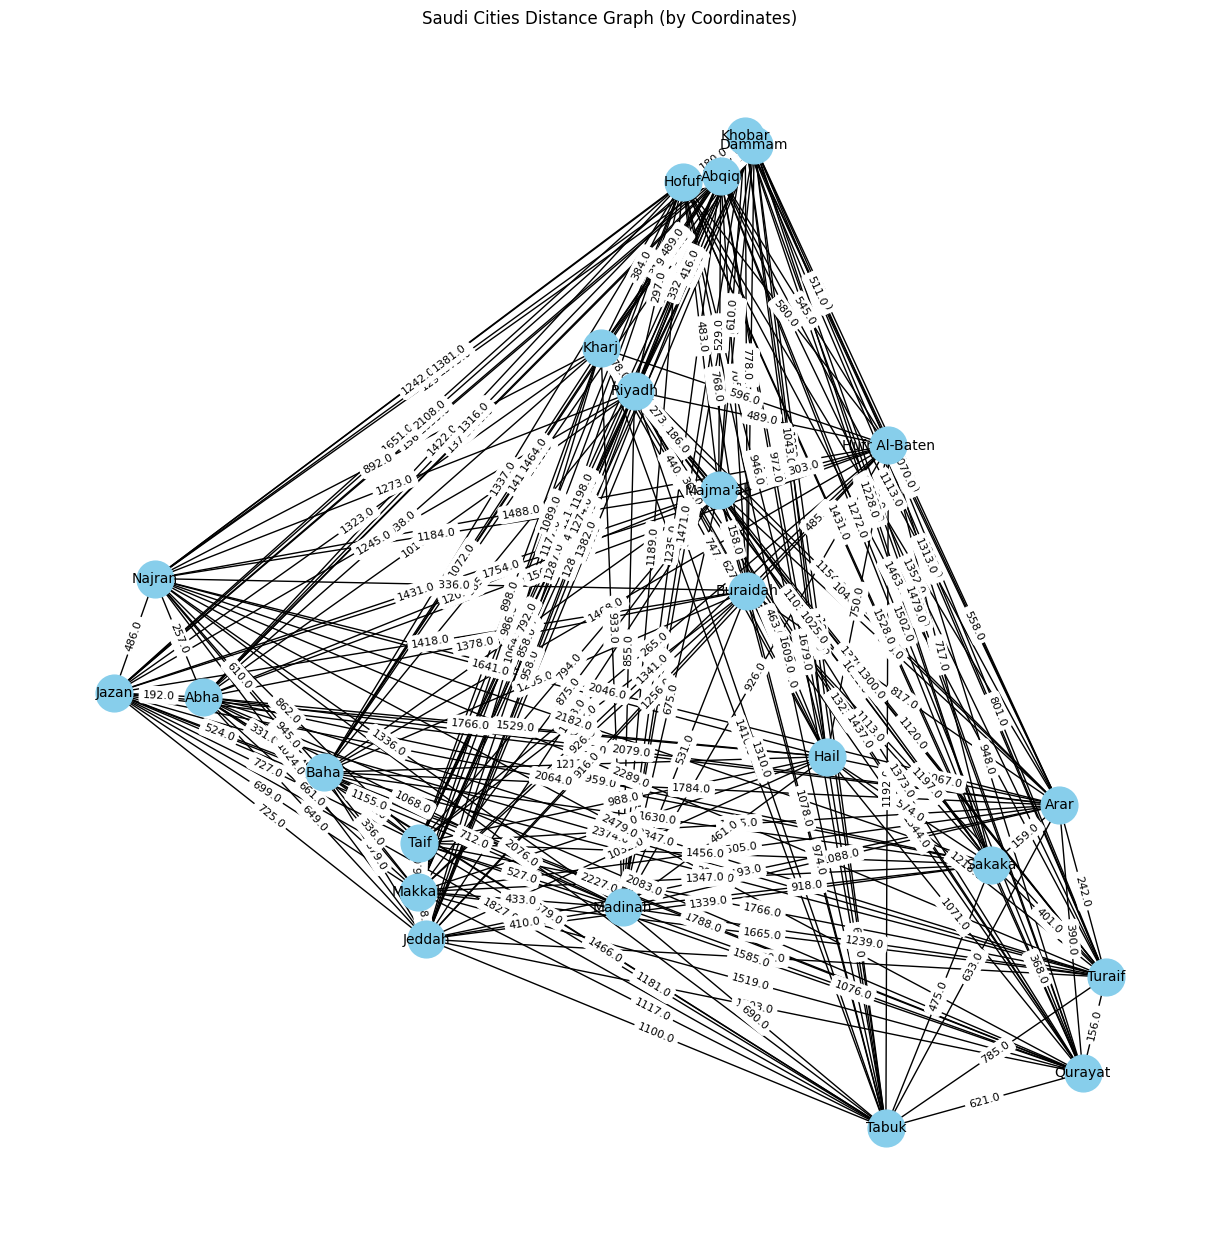

In [ ]:
import networkx as nx
G = nx.Graph()

for city in df.index:
    G.add_node(city)

for i, city1 in enumerate(df.index):
    for j, city2 in enumerate(df.columns):
        if i < j and df.iloc[i, j] != 0 and df.iloc[i, j] != float('inf'):
            G.add_edge(city1, city2, weight=df.iloc[i, j])

pos = {city: city_to_coords[city] for city in df.index}

plt.figure(figsize=(12, 12))
nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue', font_size=10)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)
plt.title('Saudi Cities Distance Graph (by Coordinates)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# **1. Gentic Algorithm**

https://www.geeksforgeeks.org/dsa/genetic-algorithms/

In [ ]:
#new
def create_route(n):

    n = len(cities)
    route = np.random.permutation(n)
    return route


In [ ]:
def initial_population(pop_size, n):
    return [create_route(n) for _ in range(pop_size)]

In [ ]:
chromosome = initial_population(1, len(distance_matrix))
print(chromosome)

[array([17, 13, 12,  5,  8, 20,  1,  4,  0,  2,  6, 11, 15,  9, 18, 10,  7,
       16, 19,  3, 22, 21, 14])]


In [ ]:
def distance(p1, p2):
    return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5

In [ ]:
#new
def route_distance(route, distance_matrix):
    total = 0
    n = len(route)
    for i in range(n - 1):
        total += distance_matrix[route[i], route[i+1]]
    total += distance_matrix[route[-1], route[0]]  # العودة للبداية
    return total

In [ ]:
def fitness(route, coordinates):
    return 1 / route_distance(route, distance_matrix)

In [ ]:
chromosome_fitness = fitness(chromosome[0], distance_matrix)
print("Fitness of the chromosome:", chromosome_fitness)

Fitness of the chromosome: 3.561380391039567e-05


In [ ]:
def print_best_route(best_path):
    plt.figure(figsize=(8,8))
    for i, index in enumerate(best_path):
        x, y = coordinates[index]
        plt.text(x, y, str(i+1), fontsize=12, color='black', ha='right', va='top')
    plt.plot([coordinates[i][0] for i in best_path], [coordinates[i][1] for i in best_path], 'ro-')
    plt.plot([coordinates[best_path[-1]][0], coordinates[best_path[0]][0]], [coordinates[best_path[-1]][1], coordinates[best_path[0]][1]], 'ro-')
    plt.title('Best Path for the Salesman')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

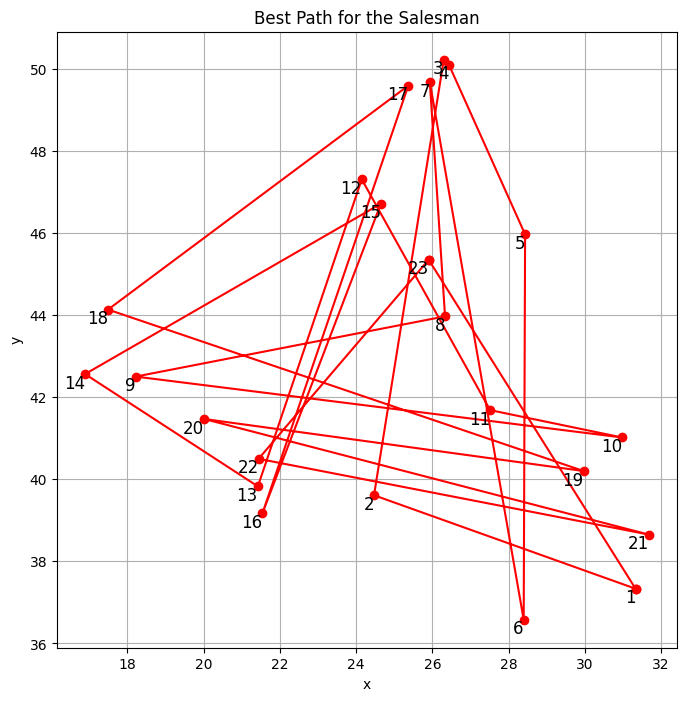

In [ ]:
print_best_route(chromosome[0])

In [ ]:
city_names = list(df.index)

In [ ]:
def crossover(parent1, parent2):
    start, end = sorted([random.randint(0, len(parent1) - 1) for _ in range(2)])
    child = [None] * len(parent1)
    child[start:end] = parent1[start:end]
    p2 = [item for item in parent2 if item not in child]
    child = [p2.pop(0) if item is None else item for item in child]
    return child

In [ ]:
def mutate(route, mutation_rate):
    for i in range(len(route)):
        if random.random() < mutation_rate:
            j = random.randint(0, len(route) - 1)
            route[i], route[j] = route[j], route[i]
    return route

In [ ]:
def plot_route(route, coordinates, generation, line):
    x = [coordinates[city][0] for city in route] + [coordinates[route[0]][0]]
    y = [coordinates[city][1] for city in route] + [coordinates[route[0]][1]]
    line.set_data(x, y)
    plt.title(f"Generation {generation + 1}")

In [ ]:
def genetic_algorithm(distance_matrix, pop_size=300, elite_size=30, mutation_rate=0.01, generations=1000):
    n = len(distance_matrix)
    population = initial_population(pop_size, n)
    history = []
    for gen in range(generations):
        # Rank routes based on fitness
        population = sorted(population, key=lambda x: fitness(x, distance_matrix), reverse=True)
        # Select the best routes to be parents
        parents = population[:elite_size]
        # Generate children
        children = []
        for _ in range(pop_size - elite_size):
            parent1, parent2 = random.sample(parents, 2)
            child = crossover(parent1, parent2)
            children.append(mutate(child, mutation_rate))
        # Form the new population
        population = parents + children
        # Best route and distance of the current generation
        best_route = population[0]
        best_distance = route_distance(best_route, distance_matrix)
        history.append((best_route, gen, best_distance))
    best_route = population[0]

    best_distance = route_distance(best_route, distance_matrix)
    return history, best_route, best_distance

In [ ]:
%%time

history_GA, best_route_GA, best_distance_GA = genetic_algorithm(distance_matrix)
print("Best route:", best_route_GA)
print("Best distance:", best_distance_GA)

Best route: [np.int64(21), np.int64(15), np.int64(10), np.int64(9), np.int64(0), np.int64(16), np.int64(3), np.int64(13), np.int64(20), np.int64(17), np.int64(22), np.int64(2), np.int64(19), np.int64(6), np.int64(4), np.int64(14), np.int64(18), np.int64(11), np.int64(7), np.int64(1), np.int64(12), np.int64(5), np.int64(8)]
Best distance: 7103.0
CPU times: user 12.9 s, sys: 3.82 ms, total: 12.9 s
Wall time: 13 s


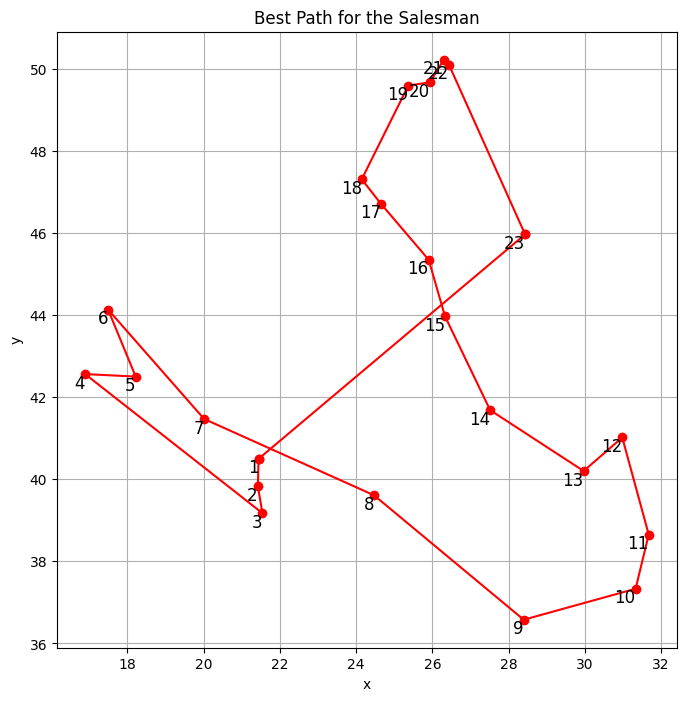

In [ ]:
print_best_route(best_route_GA)

In [ ]:
city_names = list(df.index)
named_path = [city_names[i] for i in best_route_GA]
print("Best path by names:", " -> ".join(named_path))

Best path by names: Taif -> Makkah -> Jeddah -> Jazan -> Abha -> Najran -> Baha -> Madinah -> Tabuk -> Qurayat -> Turaif -> Arar -> Sakaka -> Hail -> Buraidah -> Majma'ah -> Riyadh -> Kharj -> Hofuf -> Abqiq -> Khobar -> Dammam -> Hufr Al-Baten


# **2. HILL CLIMBING**

Hill climbing follows these steps:

1. Initial State: Start with an arbitrary or random solution (initial state).
2. Neighboring States: Identify neighboring states of the current solution by making small adjustments (mutations or tweaks).
3. Move to Neighbor: If one of the neighboring states offers a better solution (according to some evaluation function), move to this new state.

4. Termination: Repeat this process until no neighboring state is better than the current one. At this point, we have reached a local maximum or minimum.
https://www.geeksforgeeks.org/artificial-intelligence/introduction-hill-climbing-artificial-intelligence/

In [ ]:
def get_neighbor(route):
    route = route.copy()
    i, j = np.random.choice(len(route), 2, replace=False)
    route[i], route[j] = route[j], route[i]
    return route

def hill_climbing(distance_matrix, n_iterations=1000):
    n_coordinates = len(distance_matrix)
    current_route = np.random.permutation(n_coordinates)
    current_distance = route_distance(current_route, distance_matrix)
    best_route = current_route
    best_distance = current_distance

    history = [best_distance]

    for _ in range(n_iterations):
        neighbor = get_neighbor(current_route)
        neighbor_distance = route_distance(neighbor, distance_matrix)

        if neighbor_distance < current_distance:
            current_route = neighbor
            current_distance = neighbor_distance

            if current_distance < best_distance:
                best_route = current_route
                best_distance = current_distance

        history.append(best_distance)

    return best_route, best_distance, history

best_route_hc, best_dist_hc, history_hc = hill_climbing(distance_matrix)
best_dist_hc

np.float64(9162.0)

In [ ]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "Algorithm": ["Genetic Algorithm", "Hill-Climbing"],
        "Best distance": [best_distance_GA, best_dist_hc],
    }
)

comparison

,Algorithm,Best distance
0,Genetic Algorithm,7103.0
1,Hill-Climbing,9162.0


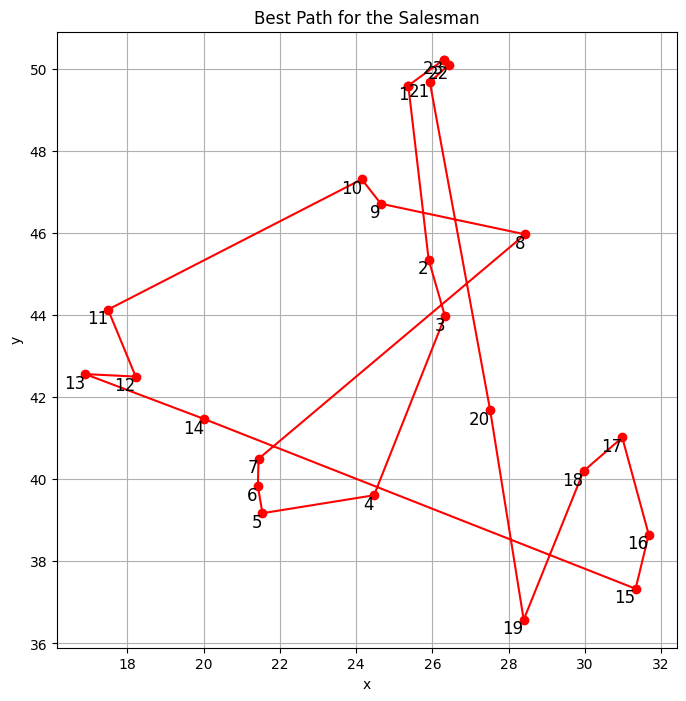

In [ ]:
print_best_route(best_route_hc)

In [ ]:
named_path = [city_names[i] for i in best_route_hc]
print("Best path by names:", " -> ".join(named_path))

Best path by names: Hofuf -> Majma'ah -> Buraidah -> Madinah -> Jeddah -> Makkah -> Taif -> Hufr Al-Baten -> Riyadh -> Kharj -> Najran -> Abha -> Jazan -> Baha -> Qurayat -> Turaif -> Arar -> Sakaka -> Tabuk -> Hail -> Abqiq -> Dammam -> Khobar


# **3. SIMULATED ANNEALING**

In [ ]:

def simulated_annealing(distance_matrix, initial_temp=50000, cooling_rate=0.9995, n_iterations=50000):
    n = len(distance_matrix)
    current_route = np.random.permutation(n)
    current_distance = route_distance(current_route, distance_matrix)
    best_route = current_route.copy()
    best_distance = current_distance
    temp = initial_temp
    history = [best_distance]

    for _ in range(n_iterations):

        neighbor = current_route.copy()
        i, j = np.random.choice(n, 2, replace=False)
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        neighbor_distance = route_distance(neighbor, distance_matrix)


        if neighbor_distance < current_distance or np.random.rand() < np.exp((current_distance - neighbor_distance) / temp):
            current_route = neighbor
            current_distance = neighbor_distance
            if current_distance < best_distance:
                best_route = current_route.copy()
                best_distance = current_distance

        history.append(best_distance)
        temp *= cooling_rate

    return best_route, best_distance, history



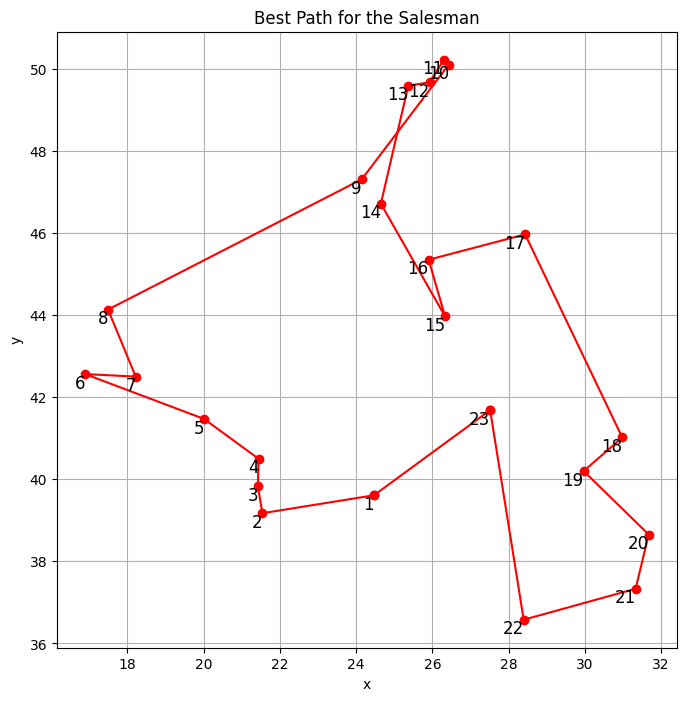

In [ ]:

best_route_sa, best_dist_sa, history_sa = simulated_annealing(distance_matrix)

print_best_route(best_route_sa)

In [ ]:
named_path = [city_names[i] for i in best_route_sa]
print("Best path by names:", " -> ".join(named_path))

Best path by names: Madinah -> Jeddah -> Makkah -> Taif -> Baha -> Jazan -> Abha -> Najran -> Kharj -> Dammam -> Khobar -> Abqiq -> Hofuf -> Riyadh -> Buraidah -> Majma'ah -> Hufr Al-Baten -> Arar -> Sakaka -> Turaif -> Qurayat -> Tabuk -> Hail


In [ ]:
best_dist_sa

np.float64(7362.0)

In [ ]:
comparison = pd.DataFrame(
    {
        "Algorithm": ["Genetic Algorithm", "Hill-Climbing","Simulated Annealing"],
        "Best distance": [best_distance_GA, best_dist_hc,best_dist_sa],
    }
)

comparison

,Algorithm,Best distance
0,Genetic Algorithm,7103.0
1,Hill-Climbing,9162.0
2,Simulated Annealing,7362.0


# **4. Evolutionary Strategies**

https://www.kaggle.com/code/pawelkauf/introduction-to-evolutionary-strategies

In [ ]:

def evolutionary_strategies(distance_matrix, population_size=200, n_iterations=2000 , mutation_rate=0.3):
    n = len(distance_matrix)

    population = [np.random.permutation(n) for _ in range(population_size)]
    best_route = None
    best_distance = float('inf')
    history = []

    for _ in range(n_iterations):

        distances = [route_distance(ind, distance_matrix) for ind in population]

        min_idx = np.argmin(distances)
        if distances[min_idx] < best_distance:
            best_distance = distances[min_idx]
            best_route = population[min_idx].copy()
        history.append(best_distance)


        new_population = [best_route.copy()]
        while len(new_population) < population_size:
            parent = best_route.copy()
            if np.random.rand() < mutation_rate:
                i, j = np.random.choice(n, 2, replace=False)
                parent[i], parent[j] = parent[j], parent[i]
            new_population.append(parent)
        population = new_population

    return best_route, best_distance, history



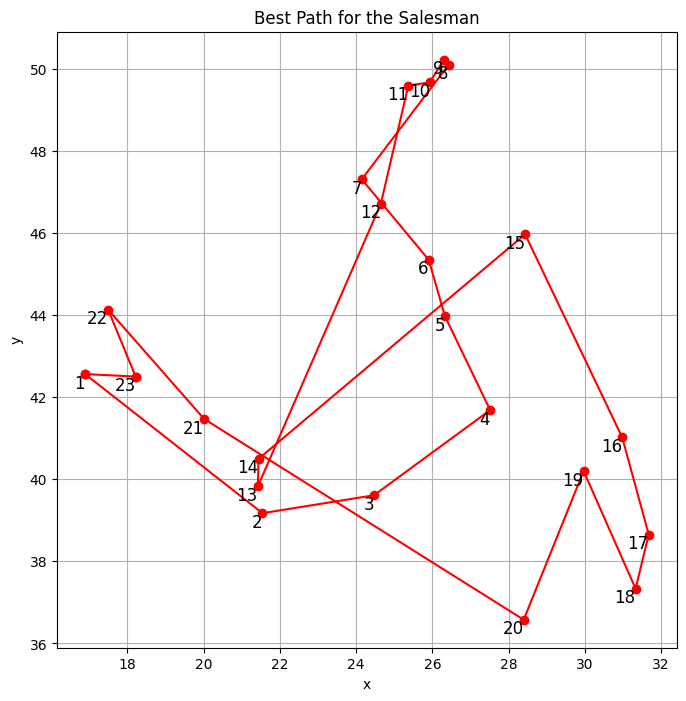

In [ ]:

best_route_es, best_dist_es, history_es = evolutionary_strategies(distance_matrix)

print_best_route(best_route_es)

In [ ]:
named_path = [city_names[i] for i in best_route_es]
print("Best path by names:", " -> ".join(named_path))

Best path by names: Jazan -> Jeddah -> Madinah -> Hail -> Buraidah -> Majma'ah -> Kharj -> Dammam -> Khobar -> Abqiq -> Hofuf -> Riyadh -> Makkah -> Taif -> Hufr Al-Baten -> Arar -> Turaif -> Qurayat -> Sakaka -> Tabuk -> Baha -> Najran -> Abha


In [ ]:
best_dist_es

np.float64(8704.0)

In [ ]:
comparison = pd.DataFrame(
    {
        "Algorithm": ["Genetic Algorithm", "Hill-Climbing","Simulated Annealing","evolutionary_strategies"],
        "Best distance": [best_distance_GA, best_dist_hc,best_dist_sa,best_dist_es],
    }
)

comparison

,Algorithm,Best distance
0,Genetic Algorithm,7103.0
1,Hill-Climbing,9162.0
2,Simulated Annealing,7362.0
3,evolutionary_strategies,8704.0


In [ ]:
print(city_names)

['Abha', 'Abqiq', 'Arar', 'Baha', 'Buraidah', 'Dammam', 'Hail', 'Hofuf', 'Hufr Al-Baten', 'Jazan', 'Jeddah', 'Kharj', 'Khobar', 'Madinah', "Majma'ah", 'Makkah', 'Najran', 'Qurayat', 'Riyadh', 'Sakaka', 'Tabuk', 'Taif', 'Turaif']


# **Informed Algorith: Branch And Bound**

ref. https://www.geeksforgeeks.org/dsa/traveling-salesman-problem-using-branch-and-bound-2/

In [ ]:
import heapq
class Data:
    def __init__(self, number_of_cities, file_path):
        self.number_of_cities = number_of_cities
        self.file_path = file_path
        self.cities = None

    def load_data(self):
        self.cities = np.genfromtxt(self.file_path, delimiter=',', skip_header=1, usecols=range(1, self.number_of_cities+1))
        print("\033[32mData loaded!\033[0m")

# كلاس Branch and Bound
class Node:
    def __init__(self, n=0):
        self.matrix = [[float('inf')] * n for _ in range(n)]
        self.cost = 0
        self.vertex = 0
        self.level = 0
        self.path = []
    def __lt__(self, other):
        return self.cost < other.cost

def reduce_matrix(mat):
    n = len(mat)
    reduction = 0
    # row reduction
    for i in range(n):
        row_min = min(mat[i])
        if row_min != float('inf') and row_min > 0:
            reduction += row_min
            for j in range(n):
                if mat[i][j] != float('inf'):
                    mat[i][j] -= row_min
    # column reduction
    for j in range(n):
        col_min = min(mat[i][j] for i in range(n))
        if col_min != float('inf') and col_min > 0:
            reduction += col_min
            for i in range(n):
                if mat[i][j] != float('inf'):
                    mat[i][j] -= col_min
    return reduction

def create_child(parent, from_city, to):
    n = len(parent.matrix)
    child = Node(n)
    child.matrix = [row[:] for row in parent.matrix]
    for j in range(n):
        child.matrix[from_city][j] = float('inf')
    for i in range(n):
        child.matrix[i][to] = float('inf')
    edge_cost = parent.matrix[from_city][to]
    child.cost = parent.cost + edge_cost
    reduction = reduce_matrix(child.matrix)
    child.cost += reduction
    child.vertex = to
    child.level = parent.level + 1
    child.path = parent.path[:]
    child.path.append(to)
    return child

def solve_tsp(cost_matrix):
    n = len(cost_matrix)
    root = Node(n)
    root.matrix = [list(row) for row in cost_matrix]
    root.vertex = 0
    root.level = 0
    root.path.append(0)
    root.cost = reduce_matrix(root.matrix)
    pq = []
    heapq.heappush(pq, root)
    best_cost = float('inf')
    best_path = []
    while pq:
        cur = heapq.heappop(pq)
        if cur.cost >= best_cost:
            continue
        if cur.level == n - 1:
            final_edge = cur.matrix[cur.vertex][0]
            if final_edge == float('inf'):
                continue
            total_cost = cur.cost + final_edge
            if total_cost < best_cost:
                best_cost = total_cost
                best_path = cur.path[:]
                best_path.append(0)
            continue
        for j in range(n):
            if cur.matrix[cur.vertex][j] != float('inf') and j not in cur.path:
                child = create_child(cur, cur.vertex, j)
                if child.cost < best_cost:
                    heapq.heappush(pq, child)
    return best_cost, best_path

num_cities = 12
file_path = '/content/TSP_KSA/ksa_distance_matrix.csv'

data = Data(num_cities, file_path)
data.load_data()
cost_matrix = data.cities[:num_cities, :num_cities]

best_cost, best_path = solve_tsp(cost_matrix)
if best_cost == float('inf'):
    print("No Hamiltonian cycle found")
else:
    print("Minimum cost:", best_cost)
    print("Path:", best_path)


Data loaded!
Minimum cost: 5761.0
Path: [0, 9, 3, 10, 6, 4, 2, 8, 5, 1, 7, 11, 0]


In [ ]:
comparison = pd.DataFrame(
    {
        "Algorithm": ["Genetic Algorithm", "Hill-Climbing","Simulated Annealing","evolutionary_strategies","Branch And Bound"],
        "Best distance": [best_distance_GA, best_dist_hc,best_dist_sa,best_dist_es,best_cost],
    }
)

comparison

,Algorithm,Best distance
0,Genetic Algorithm,7103.0
1,Hill-Climbing,9162.0
2,Simulated Annealing,7362.0
3,evolutionary_strategies,8704.0
4,Branch And Bound,5761.0


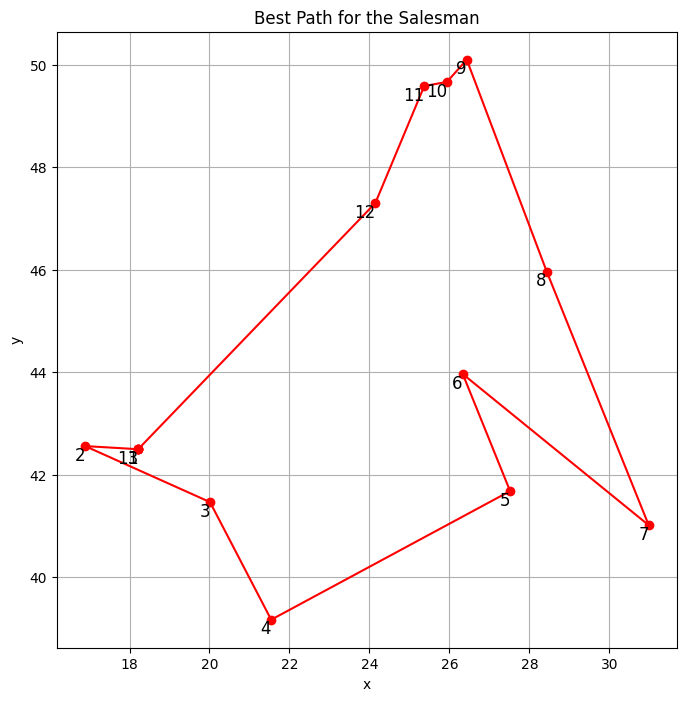

In [ ]:
print_best_route(best_path)

In [ ]:
named_path = [city_names[i] for i in best_path]
print("Best path by names:", " -> ".join(named_path))

Best path by names: Abha -> Jazan -> Baha -> Jeddah -> Hail -> Buraidah -> Arar -> Hufr Al-Baten -> Dammam -> Abqiq -> Hofuf -> Kharj -> Abha
